<div style="background: linear-gradient(135deg, #1e4078 0%, #3464af 100%); padding: 32px 28px; border-radius: 12px; color: white; margin-bottom: 8px;">
  <h1 style="margin:0; font-size:2em; font-weight:800;">Programming Assignment</h1>
  <h2 style="margin:6px 0 0 0; font-weight:400; opacity:0.9;">Neural Networks from Scratch — FashionMNIST Classifier</h2>
  <p style="margin:10px 0 0 0; opacity:0.75; font-size:0.95em;">DSE 220 MAS &nbsp;|&nbsp; Backpropagation, SGD, Activations</p>
</div>

> **Instructions:** Complete every `# TODO` block. Run all cells before submitting. All code, plots, and written answers belong in this notebook.
>
> **Allowed libraries:** `numpy`, `matplotlib`, `PIL`, `os`, `random`, `yaml`  
> **Forbidden:** `scipy`, `sklearn`, `tensorflow`, `keras`, `torch` *(except for the data download cell)*
>
> **AI Use Policy:** If you used ChatGPT / Copilot, document every instance in the *AI Use Log* cell at the end.

## 📋 Table of Contents
1. [Setup & Imports](#setup)
2. [Abstract](#abstract)
3. [Data Visualization](#viz)
4. [Data Loading & Preprocessing](#data)
5. [Core Architecture](#arch)
6. [Training Loop](#train)
7. [Rubric #4 — Softmax Regression](#softmax)
8. [Rubric #5 — Gradient Check](#gradcheck)
9. [Rubric #6 — Activation Experiments](#activation)
10. [Summary of Results](#summary)
11. [Team Contributions](#team)
12. [AI Use Log](#ailog)

---
## 1. Setup & Imports <a id='setup'></a>

In [ ]:
# Run this cell first to install/verify dependencies
!pip install numpy matplotlib pyyaml Pillow --quiet

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import yaml
import random
import copy

# PyTorch is only used here for the initial data download
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

np.random.seed(42)
random.seed(42)
print('All imports successful.')

All imports successful.


---
## 2. Abstract *(2 pts)* <a id='abstract'></a>

> **Instructions:** Write a short paragraph (4–6 sentences) summarising what you did, your approach, key findings, and **final test accuracy** results for each experiment (report % correct, not loss values).

  In PA1 we implemented a fully connected neural network from scratch using only numpy, including forward and backward propagation, mini batch SGD, and early stopping. We trained three different models on the FashionMNIST dataset, which is a single layer softmax regression baseline, and two hidden layer networks using sigmoid, tanh, and ReLU activations.

  At the start of the data project we intially did EDA to find out the exactly the time of data we were working with. By visualizing and analyzing the file type we were better able to expand into further sections of the projects. A big hurdle we were challenged with was the ambiguity of shape for specific articles of clothing. Understanding this early on allowed for us to better research how we could shape our model. We then normalized the data by individual image so we could shape our model to better capture shape of clothing as opposed to the various lighting a clothing article may be exposed to. After splitting the data and preparing our activation function we were ready to begin running regressions.

Our best model used tanh activation and achieved 85.6% test accuracy, outperforming the softmax baseline of 84.2% and ReLU at 76.8%. Sigmoid failed to learn in a useful way, stuck at 10% due to vanishing gradients across the two hidden layers. We found that activation function choice has a pretty big impact on model performance, & that tanh outperformed ReLU in this configuration, likely because its outputs provided more stable gradient updates across the hidden layers.

---
## 3. Data Visualization *(1 pt)* <a id='viz'></a>

Before working with data numerically, it is always good practice to visually inspect a few samples. Below we display images from the FashionMNIST dataset to understand what we are classifying.

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 333kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.00MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.5MB/s]


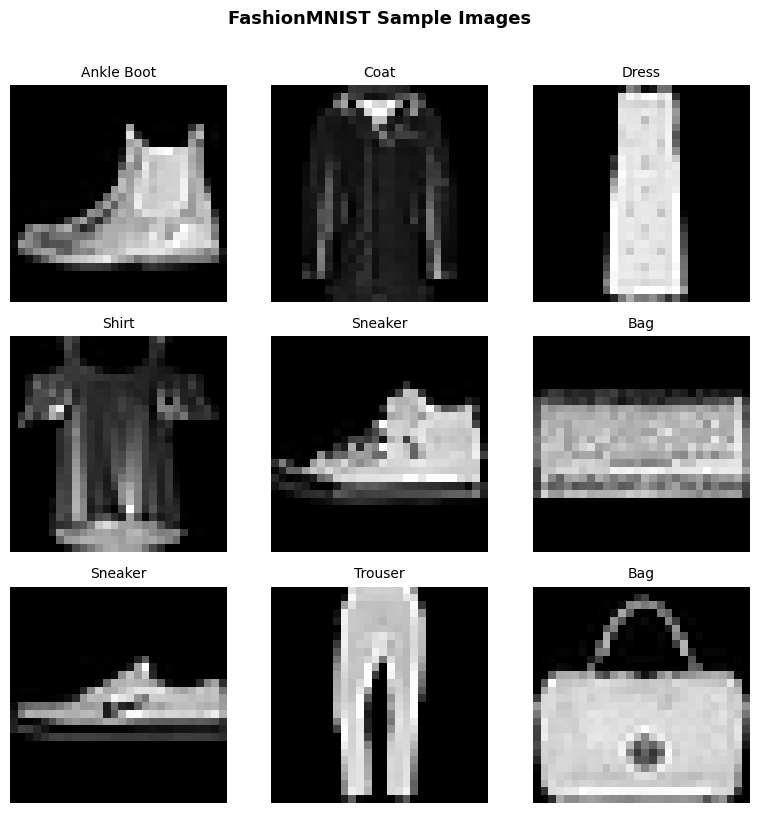

In [ ]:
# Download data for visualization using PyTorch (allowed for download only)
train_data_torch = datasets.FashionMNIST(root='data', train=True, download=True, transform=ToTensor())
test_data_torch  = datasets.FashionMNIST(root='data', train=False, download=True, transform=ToTensor())

labels_map = {
    0: "T-Shirt", 1: "Trouser",   2: "Pullover", 3: "Dress",  4: "Coat",
    5: "Sandal",  6: "Shirt",     7: "Sneaker",  8: "Bag",    9: "Ankle Boot"
}

# ── Display a 3x3 grid of random FashionMNIST images ─────────────────────────
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data_torch), size=(1,)).item()
    img, label = train_data_torch[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label], fontsize=10)
    plt.axis('off')
    plt.imshow(img.squeeze(), cmap='gray')
plt.suptitle('FashionMNIST Sample Images', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

✏️ **Written Answer:** Why might certain classes be harder to distinguish from each other?

**The lack of detail; the pictures given roughly give a silhouette of the object. I believe the ML will capture details from this silhouette which could be ambiguous with another similar clothing object.**

---
## 4. Data Loading & Preprocessing *(2 pts)* <a id='data'></a>

Raw pixel values range from 0–255 and vary widely across images. We **z-score normalize** each image individually (subtract its own mean, divide by its own std) so that pixel values are roughly centered around 0 with unit variance. This stabilizes gradient updates and speeds up convergence.

In [ ]:
# Convert PyTorch datasets to numpy arrays and save locally
# (Run once — will skip if files already exist)

path = 'data/numpy/'
os.makedirs(path, exist_ok=True)

if not os.path.exists(f'{path}/train_features.npy'):
    print('Converting to numpy ...')
    def dataset_to_numpy(ds):
        imgs, labs = [], []
        for img, lab in DataLoader(ds, batch_size=1, shuffle=False):
            imgs.append(img.squeeze().numpy())
            labs.append(lab.item())
        return np.array(imgs), np.array(labs)

    train_im, train_lab = dataset_to_numpy(train_data_torch)
    test_im,  test_lab  = dataset_to_numpy(test_data_torch)

    np.save(f'{path}train_features.npy', train_im)
    np.save(f'{path}train_labels.npy',   train_lab)
    np.save(f'{path}test_features.npy',  test_im)
    np.save(f'{path}test_labels.npy',    test_lab)
    print('Done.')
else:
    print('Numpy files already exist — skipping.')

Converting to numpy ...
Done.


In [ ]:
def normalize_data(inp):
    """
    Z-score normalize each image individually.

    Args:
        inp : np.ndarray of shape (N, d)
    Returns:
        normalized : np.ndarray of shape (N, d), mean~0, std~1 per row

    Hint:
        - Compute mean along axis=1 with keepdims=True -> shape (N, 1)
        - Same for std — use inp.std(axis=1, keepdims=True)
        - Guard against std == 0 (uniform images) by replacing 0 with 1
        - z-score normalized = (x - img_mean) / img_std
    """
    # TODO: implement z-score normalization per image

    img_mean = np.mean(inp, axis=1, keepdims=True)   # shape (N, 1)
    img_std  = np.std(inp, axis=1, keepdims=True) # shape (N, 1)
    # Avoid division by zero for uniform images (std == 0)
    img_std  = np.where(img_std == 0, 1, img_std)
    normalized = (inp - img_mean) / img_std
    return normalized

In [ ]:
def one_hot_encoding(labels, num_classes=10):
    """
    Convert integer labels to one-hot encoded matrix.
    Example:
        label 3  →  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

    Args:
        labels      : np.ndarray of shape (N, 1) — integer class indices
        num_classes : int — number of distinct classes (10 for FashionMNIST)
    Returns:
        one_hot : np.ndarray of shape (N, num_classes)

    Hint:
        Create a zeros matrix of shape (N, num_classes).
        For each row i, place a 1 in the column matching labels[i].
    """
    # TODO: implement one-hot encoding
    # Labels comes in as shape (N,1), a col vector. Indexing np.eye(10) later on with a 2d array makes a 3d array
    # need to flatten so after its indexed it makes correct 2D shape
    one_hot = np.eye(num_classes)[labels.flatten()]
    return one_hot

In [ ]:
def create_train_val_split(x_train, y_train, val_ratio=0.2):
    """
    Shuffle data, then split into 80% train / 20% validation.

    Args:
        x_train   : np.ndarray (N, d)
        y_train   : np.ndarray (N, 1)
        val_ratio : float — fraction for validation (default 0.2)
    Returns:
        x_tr, y_tr, x_val, y_val

    Hint:
        Use np.random.permutation to shuffle indices, then slice.
    """
    n = x_train.shape[0]
    perm = np.random.permutation(n)
    x_train, y_train = x_train[perm], y_train[perm]
    split = int(n * (1 - val_ratio))
    # TODO: Fill in the sliced indices for x_train, y_train, x_val, y_val
    return x_train[:split], y_train[:split], x_train[split:], y_train[split:]




In [ ]:
# ── Load raw data ─────────────────────────────────────────────────────────────
train_images = np.load('data/numpy/train_features.npy').reshape(60000, -1)  # (60000, 784)
train_labels = np.load('data/numpy/train_labels.npy')
test_images  = np.load('data/numpy/test_features.npy').reshape(10000, -1)   # (10000, 784)
test_labels  = np.load('data/numpy/test_labels.npy')

train_labels = train_labels.reshape(-1, 1)
test_labels  = test_labels.reshape(-1, 1)

print(f'Train: {train_images.shape}, Test: {test_images.shape}')

# ── Train / Validation split ──────────────────────────────────────────────────
x_train, y_train, x_val, y_val = create_train_val_split(train_images, train_labels)
x_test, y_test = test_images, test_labels

print(f'After split — Train: {x_train.shape}, Val: {x_val.shape}')

# ── Normalize ─────────────────────────────────────────────────────────────────
x_train_norm = normalize_data(x_train)
x_val_norm   = normalize_data(x_val)
x_test_norm  = normalize_data(x_test)

# ── One-hot encode ────────────────────────────────────────────────────────────
y_train_oh = one_hot_encoding(y_train)
y_val_oh   = one_hot_encoding(y_val)
y_test_oh  = one_hot_encoding(y_test)

# ── Report mean and std for one training image (BEFORE normalization) ─────────
sample_idx = 0
print(f'\nSample image #{sample_idx} (BEFORE AND AFTER normalization):')
print(f'  Mean before norm: {x_train[sample_idx].mean():.4f}')
print(f'  Std  before norm: {x_train[sample_idx].std():.4f}')
print(f'  Mean after  norm: {x_train_norm[sample_idx].mean():.4f}')
print(f'  Std  after  norm: {x_train_norm[sample_idx].std():.4f}')

Train: (60000, 784), Test: (10000, 784)
After split — Train: (48000, 784), Val: (12000, 784)

Sample image #0 (BEFORE AND AFTER normalization):
  Mean before norm: 0.3312
  Std  before norm: 0.3187
  Mean after  norm: -0.0000
  Std  after  norm: 1.0000


✏️ **Written Answer (Data Loading):** Describe the dataset, how you split it, and the normalization procedure. Report the mean and std values you printed above. Why is per-image normalization preferable to global normalization for this task?

The data set has 60k training & 10k test greyscale images across 10 clothing categories. Each image is 28x28 pixels flattend into 784 values. Training set was split 80/20 into 48k training & 12k validation examples.

Z-score normalization was applied to each image, which resulted in a mean of 0 and std of 1. You want to normalize each image to global because each image has very different levels of brightness. We want out model to capture shape and texture as opposed to lighting. IF we used global normalization the brightness imbalance would not be filtered out. Per image normalization puts every image on the same scale, regardless of how bright or dark it is.

---
## 5. Core Architecture <a id='arch'></a>

### 5.1 Activation Functions

Each hidden layer passes its weighted sum $a$ through a non-linear activation $g(a)$, which allows the network to learn complex decision boundaries. Without non-linearities, stacking layers would collapse to a single linear transformation.

| Activation | Formula | Gradient |
|:---:|:---:|:---:|
| Sigmoid | $\frac{1}{1+e^{-z}}$ | $\sigma(z)(1-\sigma(z))$ |
| tanh | $\tanh(z)$ | $1 - \tanh^2(z)$ |
| ReLU | $\max(0,z)$ | $\mathbb{1}[z>0]$ |
| Softmax | $\frac{e^{a_k}}{\sum_j e^{a_j}}$ | (handled by delta rule) |

> 💡 **Key insight:** The derivative is what gets used in backpropagation. It tells us "how much does the output change if I nudge the input slightly?" If the derivative is near zero (e.g., sigmoid far from 0), the gradient signal dies — this is the **vanishing gradient** problem.

In [ ]:
class Activation:
    """Wraps a single activation function and its gradient."""

    def __init__(self, activation_type='sigmoid'):
        assert activation_type in ['sigmoid', 'tanh', 'ReLU', 'output'], \
            f"Unknown activation: {activation_type}"
        self.activation_type = activation_type

    def __call__(self, z):
        return self.forward(z)

    def forward(self, z):
        if self.activation_type == 'sigmoid': return self.sigmoid(z)
        if self.activation_type == 'tanh':    return self.tanh(z)
        if self.activation_type == 'ReLU':    return self.ReLU(z)
        if self.activation_type == 'output':  return self.softmax(z)

    def backward(self, z):
        if self.activation_type == 'sigmoid': return self.grad_sigmoid(z)
        if self.activation_type == 'tanh':    return self.grad_tanh(z)
        if self.activation_type == 'ReLU':    return self.grad_ReLU(z)
        if self.activation_type == 'output':  return 1   # absorbed into delta rule

    # ── Forward functions ────────────────────────────────────────────────────
    def sigmoid(self, x):
        """sigma(x) = 1 / (1 + e^{-x})"""
        # TODO
        return  1 / (1 + np.exp(-x))


    def tanh(self, x):
        """tanh(x) — use np.tanh"""
        # TODO
        return np.tanh(x)

    def ReLU(self, x):
        """ReLU(x) = max(0, x)"""
        # TODO
        return np.maximum(0, x)

    def softmax(self, x):
        """
        Numerically stable softmax.
        Subtract row-wise max before exponentiating to prevent overflow.
        Shape in : (N, C) — N examples, C classes
        Shape out: (N, C) — each row sums to 1

        NUMERICAL STABILITY TRICK:
          Subtracting max(x) from each row before exp() prevents overflow.
          The result is mathematically identical because the constant cancels:
              exp(a - max) / sum(exp(a - max))  ==  exp(a) / sum(exp(a))

        """
        # TODO

        max = np.max(x, axis=1, keepdims=True)
        exp = np.exp(x - max)
        return exp / np.sum(exp, axis=1, keepdims=True)


    # ── Gradient functions ───────────────────────────────────────────────────
    def grad_sigmoid(self, x):
        """sigma'(x) = sigma(x)(1 - sigma(x))"""
        # TODO
        return self.sigmoid(x) * (1 - self.sigmoid(x))

    def grad_tanh(self, x):
        """tanh'(x) = 1 - tanh^2(x)"""
        # TODO
        return 1 - self.tanh(x)**2

    def grad_ReLU(self, x):
        """
        ReLU'(x) = 1 if x > 0, else 0
        Hint: return (x > 0).astype(float)
        """
        # TODO
        return (x > 0).astype(float)

### 5.2 Fully-Connected Layer

**Forward pass:** Given input $\mathbf{x} \in \mathbb{R}^{N \times d}$, we compute
$\mathbf{a} = [\mathbf{1}\,|\,\mathbf{x}]\,\mathbf{W}$ (bias prepended) and $\mathbf{z} = g(\mathbf{a})$.

**Backward pass:** Given $\boldsymbol{\delta}^{\text{cur}}$ from the layer above, compute:
1. $\nabla_W = \hat{\mathbf{x}}^\top \boldsymbol{\delta}^{\text{cur}}$
2. $\boldsymbol{\delta}^{\text{prev}} = g'(\mathbf{a}^{\text{prev}}) \odot (\boldsymbol{\delta}^{\text{cur}} \mathbf{W}_{1:}^\top)$
3. Weight update: $w \leftarrow w + \alpha \cdot \nabla_W \;/\; B$

In [ ]:
def append_bias(X):
    """Prepend a column of ones to X for the bias term. Shape: (N,d) -> (N, d+1)"""
    # TODO
    return np.hstack([np.ones((X.shape[0], 1)), X])


class Layer:
    """Fully-connected layer with bias and activation."""

    def __init__(self, in_units, out_units, activation):
        np.random.seed(42)
        self.w          = 0.01 * np.random.random((in_units + 1, out_units))  # +1 for bias
        self.x          = None   # input to this layer (with bias column)
        self.a          = None   # pre-activation weighted sum
        self.z          = None   # post-activation output
        self.dw         = 0      # gradient w.r.t. weights
        self.activation = activation

    def __call__(self, x):
        return self.forward(x)

    def forward(self, x):
        """
        Forward pass: z = activation(x_bias @ W)
        """
        # TODO
        # 1. Prepend a column of ones to x (bias trick)
        self.x = append_bias(x)                  # shape (N, in_units+1)
        # 2. Compute weighted sum (pre-activation)
        self.a =   self.x @ self.w                # shape (N, out_units)
        # 3. Apply activation function
        self.z = self.activation(self.a)                  # shape (N, out_units)
        # 4. Return post-activation output
        return  self.z

    def backward(self, deltaCur, learning_rate,
                 prev_a, prev_activation_type, gradReqd=True):
        """
        Backward pass: compute dw and propagate delta to the previous layer.

        Args:
            deltaCur            : delta from the layer above, shape (N, out_units)
            learning_rate       : scalar alpha
            prev_a              : pre-activation values of the PREVIOUS layer
            prev_activation_type: string name of prev layer's activation (for g')
            gradReqd            : if False, compute dw but do NOT update self.w

        Returns:
            delta for the previous layer, shape (N, in_units)
        """
        # TODO
        # Step 1: batch size
        batch_size = deltaCur.shape[0]
        # Step 2: activation gradient of the PREVIOUS layer
        prev_act = Activation(prev_activation_type)
        g_prime = prev_act.backward(prev_a)
                      # (N, in_units)
        # Step 3: propagate delta (skip bias row with self.w[1:])
        delta_prev = (deltaCur @ self.w[1:].T) * g_prime           # (N, in_units)
        # Step 4: weight gradient
        self.dw = self.x.T @ deltaCur / batch_size             # (in_units+1, out_units)
        # Step 5: update weights
        if gradReqd:
            self.w -= learning_rate * self.dw
        # Step 6: return delta for the layer below
        return delta_prev


### 5.3 Neural Network

The `NeuralNetwork` class assembles layers from a config dictionary, runs the full forward pass (returning loss + accuracy), and orchestrates backpropagation by calling each layer's `backward()` from output to input.

In [ ]:
def calculate_correct(y, t):
    """
    Return the fraction of examples where argmax(y) == argmax(t).

    Args:
        y : predicted probabilities, shape (N, C)
        t : one-hot targets,         shape (N, C)
    Returns:
        accuracy as a float in [0, 1]

    Hint: use np.argmax along axis=1, then compare and take np.mean.
    """
    # TODO
    return np.mean(np.argmax(y, axis=1) == np.argmax(t, axis=1))


class NeuralNetwork:
    """Fully-connected neural network assembled from a config dict."""

    def __init__(self, config):
        self.layers        = []
        specs              = config['layer_specs']
        self.num_layers    = len(specs) - 1
        self.y             = None
        self.batch_size    = config['batch_size']
        self.learning_rate = config['learning_rate']
        self.early_stop    = config['early_stop']
        self.activation    = config['activation']

        # Build layers: hidden layers use config['activation'], last layer uses 'output' (softmax)
        for i in range(self.num_layers):
            act_type = config['activation'] if i < self.num_layers - 1 else 'output'
            self.layers.append(Layer(specs[i], specs[i+1], Activation(act_type)))

    def __call__(self, x, targets=None):
        return self.forward(x, targets)

    def forward(self, x, targets=None):
        """
        Run x through all layers sequentially.
        If targets provided, return (loss, accuracy); else return raw output.

        Steps:
            1. Pass x through each layer in order
            2. Save final output as self.y
            3. If targets is not None: return (self.loss(self.y, targets),
                                               calculate_correct(self.y, targets))
            4. Else: return self.y
        """
        # TODO
        out = x
        for layer in self.layers:
            out = layer(out)
        self.y = out
        if targets is not None:
            loss = self.loss(self.y, targets)     #  — call self.loss
            acc  = calculate_correct(self.y, targets)     #  — call calculate_correct
            return loss, acc
        return self.y

    def loss(self, logits, targets):
        """
        Categorical cross-entropy loss averaged over the batch.
        Args:
            logits: The predicted logits or probabilities.
            targets: The true target labels.

        Returns:
            The categorical cross-entropy loss.

        Cross-entropy loss averaged over examples:
            L = -1/N * (sum (t * log(y)))
        Hint: use np.log(logits) and targets
        """
        # TODO
        return -np.mean(np.sum(targets * np.log(logits), axis=1))

    def backward(self, targets, gradReqd=True):
        """
        Backpropagate from the output layer to the input layer.

        Steps:
            1. Output-layer delta: deltaCur
            2. Loop i from num_layers-1 down to 0:
                 a. If i > 0: prev_a = self.layers[i-1].a  (hidden pre-activation)
                    Else:     prev_a = self.layers[0].x[:, 1:]  (strip bias from input)
                 b. prev_act = self.activation  (hidden act type for all layers)
                 c. deltaCur = self.layers[i].backward(deltaCur, self.learning_rate,
                                                       prev_a, prev_act, gradReqd)
        """
        # TODO
        # Step 1: output delta
        deltaCur = self.y - targets

        # Step 2: Loop BACKWARD: i from (num_layers-1) down to 0
        for i in range(self.num_layers - 1, -1, -1):
            # a. Get the pre-activation of the PREVIOUS layer (needed for g'):
            if i > 0:
                prev_a   = self.layers[i-1].a
            else:
                prev_a   = self.layers[0].x[:, 1:]

            # b. Get the previous layer's activation name:
            prev_act = self.activation
            deltaCur = self.layers[i].backward(deltaCur, self.learning_rate,
                                               prev_a, prev_act, gradReqd)

---
## 6. Training Loop <a id='train'></a>

Mini-batch SGD partitions the training set into batches of size $B$, runs forward + backward on each batch, then moves to the next epoch. **Early stopping** monitors validation accuracy and halts training if it does not improve for `early_stop_epoch` consecutive epochs.

In [ ]:
def model_test(model, x_test, y_test):
    """"
    Evaluate model on the test set.
    Hint: call model.forward(x_test, y_test) — it returns (loss, num_correct)
    Return (accuracy_fraction, loss)
    """
    # TODO
    loss, acc = model.forward(x_test, y_test)     # forward pass on test set
    return acc, loss


def generate_minibatches(x, y, batch_size):
    """Yield (x_batch, y_batch) tuples of size batch_size."""
    for i in range(0, len(x), batch_size):
        yield x[i:i+batch_size], y[i:i+batch_size]


def plots(train_loss, train_acc, val_loss, val_acc, early_stop_epoch=None, title_suffix=''):
    """Plot training / validation loss and accuracy curves."""
    epochs = np.arange(1, len(train_loss) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(epochs, train_loss, 'royalblue', label='Train Loss')
    axes[0].plot(epochs, val_loss,   'tomato',    label='Val Loss')
    if early_stop_epoch:
        axes[0].axvline(early_stop_epoch, color='gray', linestyle='--',
                        label=f'Early stop @ {early_stop_epoch}')
    axes[0].set_title(f'Loss {title_suffix}'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss'); axes[0].legend()
    axes[1].plot(epochs, train_acc, 'royalblue', label='Train Acc')
    axes[1].plot(epochs, val_acc,   'tomato',    label='Val Acc')
    if early_stop_epoch:
        axes[1].axvline(early_stop_epoch, color='gray', linestyle='--')
    axes[1].set_title(f'Accuracy {title_suffix}'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy'); axes[1].legend()
    plt.tight_layout(); plt.show()


def train(model, x_train, y_train, x_valid, y_valid, config):
    """
    Train using mini-batch SGD with optional early stopping.

    For each epoch:
      1. Shuffle training data
      2. Loop over mini-batches:
           a. forward pass  → get batch_loss, batch_acc
           b. backward pass
      3. Run forward on the full validation set → val_loss, val_acc
      4. Append averages to history lists
      5. Every `patience` epochs: check if val_acc improved
           - If yes: save best weights
           - If no:  restore best weights and stop
    """
    epochs    = config['epochs']
    batch_size= config['batch_size']
    early_stop= config['early_stop']
    patience  = config['early_stop_epoch']
    n         = x_train.shape[0]

    train_loss_hist, train_acc_hist = [], []
    val_loss_hist,   val_acc_hist   = [], []
    best_weights = None
    best_val_acc = -np.inf
    stopped_at   = None

    for t in range(epochs):
        # ── Step 1: Shuffle ────────────────────────────────────────────────────
        perm = np.random.permutation(n)
        x_shuf, y_shuf = x_train[perm], y_train[perm]

        # ── Step 2: Mini-batch loop ────────────────────────────────────────────
        epoch_loss, epoch_acc, n_batches = 0, 0, 0
        for x_batch, y_batch in generate_minibatches(x_shuf, y_shuf, batch_size):
            # 2a. Forward pass — returns (loss, num_correct) when targets given
            # TODO: model.forward
            batch_loss, batch_acc = model.forward(x_batch, y_batch)
            # 2b. Backward pass
            # TODO: model.backward
            model.backward(y_batch)
            epoch_loss += batch_loss
            epoch_acc  += batch_acc
            n_batches  += 1

        # ── Step 3: Validation ─────────────────────────────────────────────────
        # Run forward on the full validation set (no backward)
        # TODO: model.forward
        val_acc, val_loss = model_test(model, x_valid, y_valid)

        # ── Step 4: Append to history ──────────────────────────────────────────
        train_loss_hist.append(epoch_loss / n_batches)
        train_acc_hist.append(epoch_acc  / n_batches)
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        # ── Step 5: Early stopping ─────────────────────────────────────────────
        if early_stop and (t + 1) % patience == 0:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_weights = copy.deepcopy([layer.w for layer in model.layers])
            else:
                # Restore best weights and stop
                if best_weights is not None:
                    for layer, w in zip(model.layers, best_weights):
                        layer.w = w.copy()
                stopped_at = t + 1
                print(f'Early stopping at epoch {t+1} (best val acc = {best_val_acc:.4f})')
                break

        if (t + 1) % 10 == 0:
            print(f"Epoch {t+1}/{epochs} | "
                  f"Train Loss: {train_loss_hist[-1]:.4f} | Train Acc: {train_acc_hist[-1]:.4f} | "
                  f"Val Loss: {val_loss_hist[-1]:.4f} | Val Acc: {val_acc_hist[-1]:.4f}")

    plots(train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist, stopped_at)
    return model

---
## 7. Rubric #4 — Softmax Regression *(10 pts)* <a id='softmax'></a>

A **single-layer** network connects the 784-dimensional input directly to the 10-class softmax output. This is equivalent to multi-class logistic regression and serves as our baseline.

**Expected test accuracy: ~86%**

Epoch 10/100 | Train Loss: 0.4531 | Train Acc: 0.8441 | Val Loss: 0.4683 | Val Acc: 0.8383
Epoch 20/100 | Train Loss: 0.4262 | Train Acc: 0.8530 | Val Loss: 0.4472 | Val Acc: 0.8471
Epoch 30/100 | Train Loss: 0.4129 | Train Acc: 0.8576 | Val Loss: 0.4380 | Val Acc: 0.8488
Epoch 40/100 | Train Loss: 0.4043 | Train Acc: 0.8606 | Val Loss: 0.4352 | Val Acc: 0.8514
Epoch 50/100 | Train Loss: 0.3981 | Train Acc: 0.8622 | Val Loss: 0.4304 | Val Acc: 0.8513
Epoch 60/100 | Train Loss: 0.3934 | Train Acc: 0.8635 | Val Loss: 0.4285 | Val Acc: 0.8502
Epoch 70/100 | Train Loss: 0.3895 | Train Acc: 0.8659 | Val Loss: 0.4269 | Val Acc: 0.8521
Epoch 80/100 | Train Loss: 0.3861 | Train Acc: 0.8664 | Val Loss: 0.4254 | Val Acc: 0.8531
Epoch 90/100 | Train Loss: 0.3832 | Train Acc: 0.8670 | Val Loss: 0.4245 | Val Acc: 0.8550
Epoch 100/100 | Train Loss: 0.3807 | Train Acc: 0.8680 | Val Loss: 0.4246 | Val Acc: 0.8545


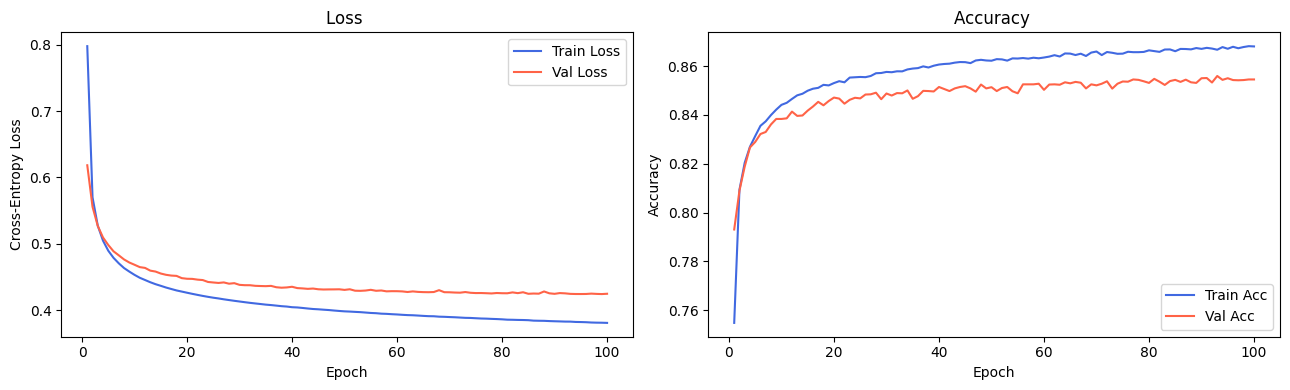


=== Softmax Regression ===
Test Accuracy : 84.22%
Test Loss     : 0.4556


In [ ]:
config_4 = {
    'layer_specs'     : [784, 10],   # input -> softmax output (no hidden layer)
    'activation'      : 'output',
    'learning_rate'   : 0.005,
    'batch_size'      : 128,
    'epochs'          : 100,
    'early_stop'      : False,
    'early_stop_epoch': 5,
}

model_softmax = NeuralNetwork(config_4)
model_softmax = train(model_softmax, x_train_norm, y_train_oh, x_val_norm, y_val_oh, config_4)

acc_softmax, loss_softmax = model_test(model_softmax, x_test_norm, y_test_oh)
print(f'\n=== Softmax Regression ===')
print(f'Test Accuracy : {acc_softmax * 100:.2f}%')
print(f'Test Loss     : {loss_softmax:.4f}')

✏️ **Written Answer (Softmax Regression):**
1. What hyperparameters did you use and why?
  - Used the provided hyperparameters: learning rate: .005, batch size: 128, 100 epochs, no early stopping. These are standard starting values for a simple softmax regression baseline.
2. Describe the shape of the loss curve.
  - The train loss drops steadily across all epochs and didn't fully converge by the end. Val loss dropped sharply in first few eppochs and then flattens around .85 for the rest.
3. What is your final test accuracy?
  - 84.22% . When learning rate was increased to .01, test accuracy slightly increased. But if we kept increasing to try and achieve 86%, it might hurt overall performance rather than help.
4. What are the limitations of a single-layer (no hidden layer) network?
- Without a hidden layer, the network can only learn linear decision boundaries. It can't capture complex patterns/relationships b/w features which limits accuracy on tasks like image classification, where relationship b/w pixels and classes is very nonlinear.

---
## 8. Rubric #5 — Backpropagation & Gradient Check *(10 pts)* <a id='gradcheck'></a>

Before trusting your backpropagation, verify it numerically. For a single weight $w$:
$$\frac{d}{dw}E^n(w) \approx \frac{E^n(w+\epsilon) - E^n(w-\epsilon)}{2\epsilon}, \quad \epsilon = 10^{-2}$$
If backprop is correct, the numerical and analytical gradients should match to within $\epsilon^2 = 10^{-4}$.

**Check 6 weights:** 1 output bias, 1 hidden bias, 2 hidden-to-output weights, 2 input-to-hidden weights.

In [ ]:
config_5 = {
    'layer_specs'     : [784, 128, 10],
    'activation'      : 'tanh',
    'learning_rate'   : 1.0,
    'batch_size'      : 128,
    'epochs'          : 1,
    'early_stop'      : False,
    'early_stop_epoch': 5,
}

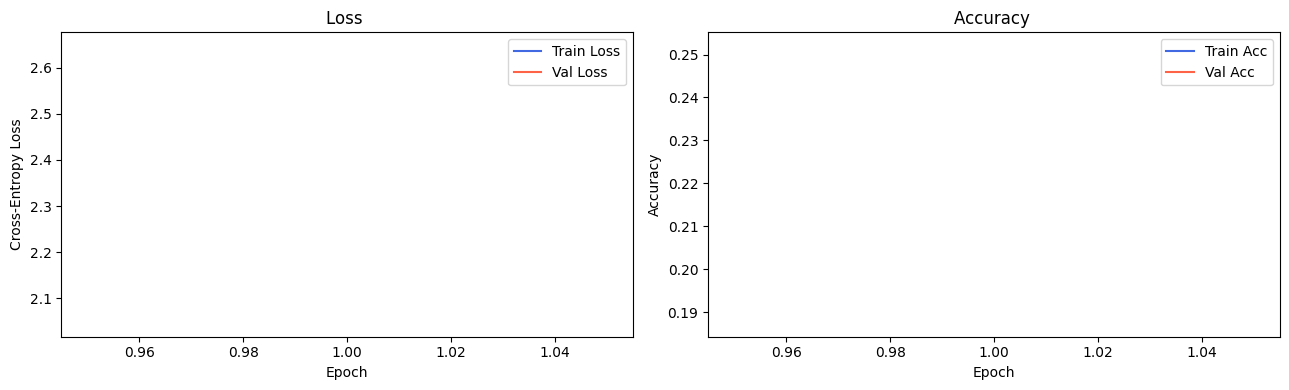


--- Gradient Check ---
Weight                              Numerical       Backprop     Abs Diff    <eps^2?
----------------------------------------------------------------------------------
Input->Hidden bias                  -0.011516      -0.011517     2.03e-07          ✓
Input->Hidden w[1][0]                0.011970       0.011970     2.28e-07          ✓
Input->Hidden w[2][0]                0.011970       0.011970     2.28e-07          ✓
Output bias                          0.008069       0.008068     1.31e-07          ✓
Hidden->Output w[1][0]              -0.003655      -0.003655     1.22e-08          ✓
Hidden->Output w[2][0]               0.001424       0.001424     7.21e-10          ✓


In [ ]:
def check_grad(model, x_sample, y_sample, epsilon=1e-2):
    """
    Compare numerical vs backprop gradients for 6 specific weights.

    The 6 weights we check:
      (layer_idx, row_in_W, col_in_W, description)
    """
    weight_specs = [
        (0, 0, 0, 'Input->Hidden bias'),
        (0, 1, 0, 'Input->Hidden w[1][0]'),
        (0, 2, 0, 'Input->Hidden w[2][0]'),
        (1, 0, 0, 'Output bias'),
        (1, 1, 0, 'Hidden->Output w[1][0]'),
        (1, 2, 0, 'Hidden->Output w[2][0]'),
    ]

    # ── Step 1: Numerical gradients via central difference ─────────────────────
    approx_grads = {}
    for (layer_idx, j, k, name) in weight_specs:
        layer = model.layers[layer_idx]
        orig  = layer.w[j, k]

        layer.w[j, k] = orig + epsilon
        loss_plus, _  = model.forward(x_sample, y_sample)

        layer.w[j, k] = orig - epsilon
        loss_minus, _ = model.forward(x_sample, y_sample)

        approx_grads[(layer_idx, j, k)] = (loss_plus - loss_minus) / (2.0 * epsilon)
        layer.w[j, k] = orig   # restore

    # ── Step 2: Backprop gradients (gradReqd=False = compute but don't update) ─
    model.forward(x_sample, y_sample)
    model.backward(y_sample, gradReqd=False)

    # ── Step 3: Print comparison table ────────────────────────────────────────
    print(f"{'Weight':<30} {'Numerical':>14} {'Backprop':>14} {'Abs Diff':>12} {'<eps^2?':>10}")
    print('-' * 82)
    for (layer_idx, j, k, name) in weight_specs:
        grad_num = approx_grads[(layer_idx, j, k)]
        grad_bp  = model.layers[layer_idx].dw[j, k]
        diff = abs(abs(grad_num) - abs(grad_bp))
        # diff     = abs(grad_num - grad_bp)
        ok       = '✓' if diff <= epsilon**2 else '✗ CHECK'
        print(f"{name:<30} {grad_num:>14.6f} {grad_bp:>14.6f} {diff:>12.2e} {ok:>10}")


model_gc = NeuralNetwork(config_5)
model_gc = train(model_gc, x_train_norm[:512], y_train_oh[:512],
                 x_val_norm[:128], y_val_oh[:128], config_5)
print('\n--- Gradient Check ---')
check_grad(model_gc, x_train_norm[:1], y_train_oh[:1])

✏️ **Written Answer (Gradient Check):**

Fill in the table below with your actual values and answer:
- Were all 6 gradients within $\epsilon^2 = 10^{-4}$?    **Yes**
- If any failed, which layer did the discrepancy occur in and what might cause it?

| Weight type | Numerical approx. | Backprop gradient | Absolute difference | Within $\epsilon^2$? |
|:---|:---:|:---:|:---:|:---:|
| Input→Hidden bias |-0.011516|-0.011517|2.03e-07|Yes
| Input→Hidden w[1][0] |0.011970|0.011970|2.28e-07|Yes
| Input→Hidden w[2][0] |0.011970|0.011970|2.28e-07|Yes
| Output bias |0.008069|0.008068|1.31e-07|Yes
| Hidden→Output w[1][0] |-0.003655|-0.003655|1.22e-08|Yes
| Hidden→Output w[2][0] |0.001424|0.001424|7.21e-10|Yes

---
## 9. Rubric #6 — Activation Function Experiments *(10 pts)* <a id='activation'></a>

The choice of activation function affects gradient flow, convergence speed, and final accuracy. Compare the three hidden-layer activations below using an otherwise identical configuration:

| Activation | Range | Key property |
|:---:|:---:|:---:|
| Sigmoid | $(0, 1)$ | Saturates → vanishing gradients |
| tanh | $(-1, 1)$ | Zero-centered, still saturates |
| ReLU | $[0, \infty)$ | Non-saturating for $x>0$, fast |

For each activation: plot the training loss and accuracy curves and report final test accuracy.


Training with activation: sigmoid
Early stopping at epoch 10 (best val acc = 0.1007)


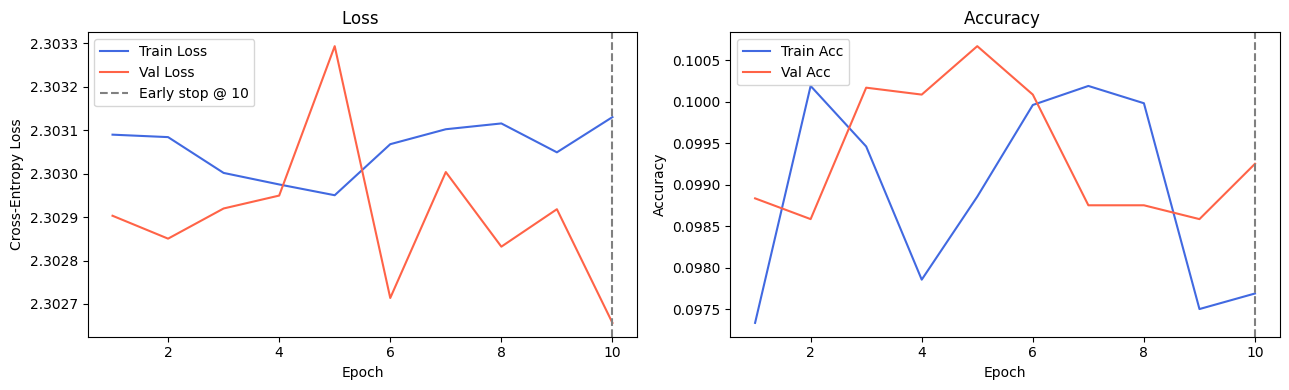

sigmoid Test Accuracy: 10.00%

Training with activation: tanh
Epoch 10/100 | Train Loss: 1.1782 | Train Acc: 0.4850 | Val Loss: 1.1627 | Val Acc: 0.4922
Epoch 20/100 | Train Loss: 0.7611 | Train Acc: 0.7344 | Val Loss: 0.7615 | Val Acc: 0.7201
Epoch 30/100 | Train Loss: 0.5431 | Train Acc: 0.8097 | Val Loss: 0.5512 | Val Acc: 0.8027
Epoch 40/100 | Train Loss: 0.4547 | Train Acc: 0.8419 | Val Loss: 0.4710 | Val Acc: 0.8367
Epoch 50/100 | Train Loss: 0.4077 | Train Acc: 0.8585 | Val Loss: 0.4308 | Val Acc: 0.8492
Epoch 60/100 | Train Loss: 0.3747 | Train Acc: 0.8688 | Val Loss: 0.4048 | Val Acc: 0.8587
Epoch 70/100 | Train Loss: 0.3488 | Train Acc: 0.8784 | Val Loss: 0.3832 | Val Acc: 0.8667
Early stopping at epoch 75 (best val acc = 0.8667)


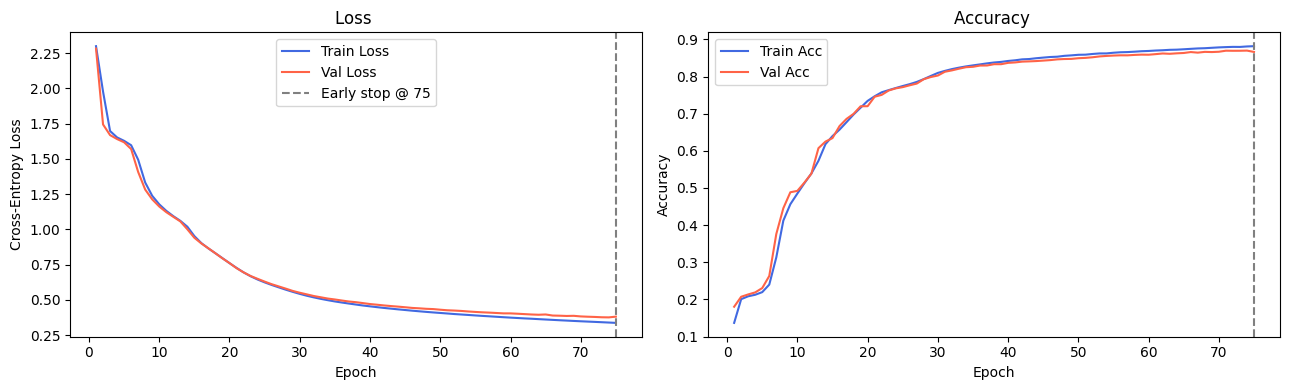

tanh Test Accuracy: 85.58%

Training with activation: ReLU
Epoch 10/100 | Train Loss: 1.4829 | Train Acc: 0.4161 | Val Loss: 1.4577 | Val Acc: 0.4221
Epoch 20/100 | Train Loss: 1.0659 | Train Acc: 0.5620 | Val Loss: 1.0677 | Val Acc: 0.5527
Epoch 30/100 | Train Loss: 0.8327 | Train Acc: 0.6532 | Val Loss: 0.8466 | Val Acc: 0.6487
Epoch 40/100 | Train Loss: 0.7441 | Train Acc: 0.7156 | Val Loss: 0.7629 | Val Acc: 0.7167
Epoch 50/100 | Train Loss: 0.6286 | Train Acc: 0.7712 | Val Loss: 0.6479 | Val Acc: 0.7691
Epoch 60/100 | Train Loss: 0.5363 | Train Acc: 0.7897 | Val Loss: 0.5672 | Val Acc: 0.7854
Early stopping at epoch 65 (best val acc = 0.7854)


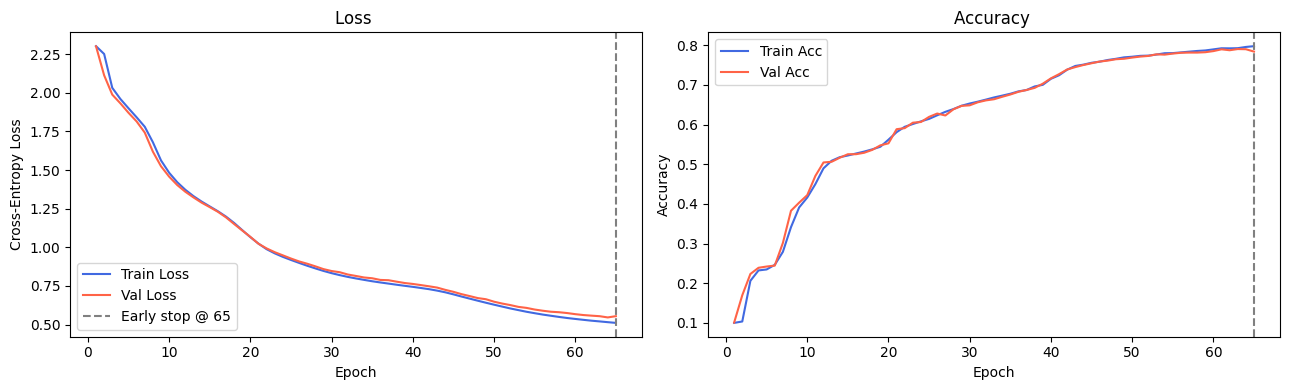

ReLU Test Accuracy: 76.84%

=== Activation Comparison ===
sigmoid   : 10.00%
tanh      : 85.58%
ReLU      : 76.84%


In [ ]:
base_config_act = {
    'layer_specs'     : [784, 256, 100, 10],
    'learning_rate'   : 0.005,
    'batch_size'      : 128,
    'epochs'          : 100,
    'early_stop'      : True,
    'early_stop_epoch': 5,
}

activation_results = {}

for act in ['sigmoid', 'tanh', 'ReLU']:
    print(f'\n{"="*50}')
    print(f'Training with activation: {act}')
    cfg = dict(base_config_act)
    cfg['activation'] = act
    model_act = NeuralNetwork(cfg)
    model_act = train(model_act, x_train_norm, y_train_oh, x_val_norm, y_val_oh, cfg)
    acc, loss = model_test(model_act, x_test_norm, y_test_oh)
    activation_results[act] = {'accuracy': acc, 'loss': loss}
    print(f'{act} Test Accuracy: {acc*100:.2f}%')

print('\n=== Activation Comparison ===')
for act, res in activation_results.items():
    print(f'{act:10s}: {res["accuracy"]*100:.2f}%')

✏️ **Written Answer (Activation Functions):**
1. Which activation performed best? Were you surprised?
- tanh performed the best at 85.6%. It was kind of suprising that tanh outperformed ReLU, because ReLU is supposed to be superior in deep networks. But with only 2 hidden layers and a smallish network, tanh's zero centered outputs probably helped the gradient flow more consistently than ReLU.
2. Did Sigmoid converge more slowly? How does this relate to the vanishing gradient problem?
- Sigmoid basically failed to converge at all, stalling at 10%. With the 2 hidden layers the sigmoid gradient gets multiplied together over and over during backprop and shrinks to practically zero before getting to input layer. Weights barely update & model never leanrs.
3. Did ReLU show any instability (NaN loss, dying neurons)? How might you address this?
- ReLU showed no NaN loss or dying neurons but converged slower than tanh and had lower accuracy. To address this you could use smaller learning rate or more training epochs to give model more time to converge.
4. Looking at the loss curves, which activation produced the smoothest training?
- tanh produced smoothest loss curve. There was a steady decline, and train/val were tracking close throughout.  

---
## 10. Summary of Results <a id='summary'></a>

Fill in the table below with your final test accuracies.

In [ ]:
from IPython.display import HTML

rows = [
    ('Softmax Regression',  'sigmoid', 'tanh', 'ReLU'),
]

# TODO: Fill in your actual test accuracies below
results = {
    'Softmax Regression' : f'{acc_softmax*100:.2f}%',
    'Sigmoid Activation' : f'{activation_results.get("sigmoid",{}).get("accuracy",0)*100:.2f}%',
    'tanh Activation'    : f'{activation_results.get("tanh",{}).get("accuracy",0)*100:.2f}%',
    'ReLU Activation'    : f'{activation_results.get("ReLU",{}).get("accuracy",0)*100:.2f}%',
}

html = """<table style='border-collapse:collapse; font-family:sans-serif; font-size:14px;'>
<tr style='background:#1e4078; color:white;'>
  <th style='padding:8px 16px;'>Experiment</th>
  <th style='padding:8px 16px;'>Test Accuracy</th>
</tr>"""
for i, (exp, acc) in enumerate(results.items()):
    bg = '#f0f4fb' if i % 2 == 0 else '#ffffff'
    html += f"""<tr style='background:{bg};'>
  <td style='padding:7px 16px;'>{exp}</td>
  <td style='padding:7px 16px; text-align:center; font-weight:bold;'>{acc}</td>
</tr>"""
html += '</table>'
display(HTML(html))

Experiment,Test Accuracy
Softmax Regression,84.22%
Sigmoid Activation,10.00%
tanh Activation,85.58%
ReLU Activation,76.84%


---
## 11. Team Contributions <a id='team'></a>

> Each team member **must** write a short paragraph (3–5 sentences) describing their individual contribution. Team members who did not contribute equally may not receive the same grade. **Everyone should have written code.**

**Team Member 1 — [Patrick Elles]:**  
✏️ I completed part of section 5.2 and on, but obviously had to review all the code from the beginning to section 5.1 to understand what everything was doing before i started on my sections. We both worked on the abstract together as a team as well as when either of us got stuck on a specific sections code.

---

**Team Member 2 — [Sam Constante]:**  
✏️ Did intial EDA for the data set, allowing intial understanding for for model creation. The questions from the begining to 5.2 were done by myself-- which assisted in the first steps of our model. Normalized the data in order to scale focus model on correct features. Defined the activation functions that were used on the model. We both worked on the abstract together as a team as well as when either of us got stuck on a specific sections code.

---
## 12. AI Use Log <a id='ailog'></a>

If you used ChatGPT, GitHub Copilot, or any other AI tool, document every instance below. If you did not use any AI tools, write **"No AI tools used."**

| # | Tool | Prompt / Task | What it generated | What you changed |
|:---:|:---:|:---|:---|:---|
| 1 |Claude | I'm getting a TypeError: unsupported operand type(s) for +: 'Activation' and 'float' — what does this mean?/ layer.forward/sigmoid bug | This error means something in your code is treating an Activation object as a number. Check your Layer.forward method. You want to be calling the activation function on your pre-activation values, not just referencing the object itself. Make sure that line is actually invoking the function.|
Changed self.z = self.activation to self.z = self.activation(self.a)
| 2 |Claude |I'm getting a TypeError: unhashable type: 'numpy.ndarray' in my sigmoid function — what does this mean? / Sigmoid bug | This error is coming from your sigmoid function. Check how you're computing e to the power of negative x in your return statement and use the correct numpy function for exponentiation.| Changed return 1 / (1 + np.e^{-x}) to return 1 / (1 + np.exp(-x))